<a href="https://colab.research.google.com/github/AcSsalazar/the-color-of-emotions/blob/main/Notebooks/4.4-transfer-learning-pytorch-tensors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Transfer Learning con ResNet-18 y EfficientNet-B0 usando tensores de Pytorch

### Introducción:

**Tensores 3D:** Datos procesados directamente con PyTorch a partir de los **Espectrograma de Mel**, **Delta de primer del espectrograma** y **Espectrograma Coclear**. Esto resulta en un tensor de entrada con la estructura `[3, Frecuencia, Tiempo en frames]`.

Analizaremos las métricas de rendimiento, los costos computacionales y, por sobre todo, el alcance de los modelos cuyos datos de entrada fueron imágenes comprimidas en comparación con aquellos entrenados con tensores, los cuales conservan de manera más íntegra la información y la dimensión temporal en sus entradas.

In [1]:
# Imports
#----------------------------------------------------------------
import os
import gc
import numpy as np
import glob
import torch
import random
import torch.nn as nn
import seaborn as sns
import torch.optim as optim
import matplotlib.pyplot as plt
#----------------------------------------------------------------
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from torchvision import datasets, transforms, models
from torchaudio import transforms as T
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from torch.cuda.amp import GradScaler, autocast
from google.colab import drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Optimizaciones de hardware y fijación de semillas para reproducibilidad
torch.manual_seed(42)
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device en uso: {device}")

Device en uso: cuda


In [4]:
# Copiamos la carpeta entera de features desde Drive al disco ultrarrápido de Colab
#!cp -r /content/drive/MyDrive/ravdess_images_02/ /content/features_local
os.makedirs('/content/', exist_ok=True)
# Opcional: Si tienes un archivo .zip en Drive, es AÚN MÁS RÁPIDO copiar el .zip y descomprimirlo localmente:
!cp -r /content/drive/MyDrive/split_pytorch_tensors/ /content

In [9]:
# Configuraciones y rutas
BASE_DIR_TENSOR = '/content/split_pytorch_tensors'
MODELS_SAVE_DIR = '/content/saved_models_TL_Pytorch'
os.makedirs(MODELS_SAVE_DIR, exist_ok=True)
# Batch por defecto = 64
BATCH_SIZE = 64
# Bandera para datos no preparados
already_normalized = True

In [7]:
# Print root_dir content:
tensor_content = (os.listdir(BASE_DIR_TENSOR))
print(f"Contenido de {BASE_DIR_TENSOR}: {tensor_content}")

Contenido de /content/split_pytorch_tensors: ['val_tensors.pt', 'test_tensors.pt', 'train_tensors.pt']


### Dataloaders con nombres de clases y metadatos

Gracias a que guardamos un pack con metadatos, donde creamos un diccionario, asociando los indices a los nombres de clases. Podemos crear una clase personalziada que extrae nuestros tensores con sus respectivos nombres de clases, y dimensiones por cada conjuntos de datos.

### Estrategia de normalización y augmentation

**Normalización:**  
Los tensores exportados en el notebook `3.2` ya fueron normalizados con **z-score por muestra y canal** (`zscore_per_channel`). Por eso `already_normalized = True` y no se aplica una segunda normalización a nivel de dataset aquí. Aplicar `CHANNEL_MEAN/CHANNEL_STD` encima del z-score por muestra introduciría una doble normalización redundante que puede distorsionar la distribución de entrada.

**Augmentation online:**  
El notebook `3.2` ya añadió muestras extra de `surprised` con **ruido** y **shift temporal** durante la exportación. En consecuencia, aquí se usa **solo SpecAugment** (FrequencyMasking + TimeMasking) como augmentation online, únicamente sobre el split de entrenamiento. No se repiten ruido ni shift para evitar acumulación de augmentations.

**WeightedRandomSampler:**  
Dado que `surprised` ya está sobre-representada por la exportación offline, `WeightedRandomSampler` está desactivado por defecto (`use_weighted_sampler=False`). Se puede activar si se regeneran los tensores sin augmentation offline.


In [26]:
SPLIT_FILES = {
    'train': 'train_tensors.pt',
    'val': 'val_tensors.pt',
    'test': 'test_tensors.pt',
}

def load_pack(split_name: str):
    path = os.path.join(BASE_DIR_TENSOR, SPLIT_FILES[split_name])
    if not os.path.exists(path):
        raise FileNotFoundError(f'No existe el archivo: {path}')
    return torch.load(path, map_location='cpu', weights_only=False)

# Cargamos los packs (aún no son tensores puros)
train_pack = load_pack('train')
val_pack = load_pack('val')
test_pack = load_pack('test')

# Verificamos las clases del diccionario dentro del pack
class_to_idx = train_pack['class_to_idx']
idx_to_class = {v: k for k, v in class_to_idx.items()}
class_names = [idx_to_class[i] for i in sorted(idx_to_class.keys())]
print('Clases:', class_names)
print('Shape train:', tuple(train_pack['x'].shape))

# CLASS_WEIGHTS siempre se calcula (es función de las etiquetas, no de la normalización)
def compute_class_weights(labels: torch.Tensor, num_classes: int):
    counts = torch.bincount(labels, minlength=num_classes).float()
    weights = counts.sum() / (counts * num_classes)
    return weights

CLASS_WEIGHTS = compute_class_weights(train_pack['y'], len(class_names))
print('Balance por clase:', torch.bincount(train_pack['y']).tolist())

# Normalización de canal solo si los tensores NO fueron pre-normalizados en la exportación.
# Con already_normalized=True los tensores ya tienen z-score por muestra (notebook 3.2),
# por lo que NO se aplica una segunda normalización a nivel de dataset.
if not already_normalized:
    MIN_STD = 1e-6

    def compute_channel_stats(x: torch.Tensor):
        x = x.float()
        mean = x.mean(dim=(0, 2, 3))
        std = x.std(dim=(0, 2, 3)).clamp_min(MIN_STD)
        return mean, std

    CHANNEL_MEAN, CHANNEL_STD = compute_channel_stats(train_pack['x'])
    print(f'CHANNEL_MEAN={CHANNEL_MEAN}, CHANNEL_STD={CHANNEL_STD}')


Clases: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Shape train: (7422, 3, 60, 51)


In [25]:
class TensorPackDataset(Dataset):
    """Dataset de tensores pre-exportados con z-score por muestra (notebook 3.2).

    Augmentation online: solo SpecAugment (FrequencyMasking + TimeMasking).
    El ruido y shift ya se aplicaron durante la exportación para 'surprised',
    por lo que NO se repiten aquí para evitar doble augmentation.
    Augmentation se aplica SOLO al split de entrenamiento (augment=True).
    """
    def __init__(self, pack, augment=False):
        self.x = pack['x'].float()  # [N, 3, n_mels, n_frames]
        self.y = pack['y'].long()
        self.augment = augment

        # SpecAugment solo para train (tamaño de entrada: 60 mel bins x 51 frames)
        if augment:
            self.spec_aug = nn.Sequential(
                T.FrequencyMasking(freq_mask_param=3),
                T.TimeMasking(time_mask_param=2)
            )

    def __len__(self):
        return self.y.shape[0]

    def __getitem__(self, idx):
        x = self.x[idx]
        y = self.y[idx]

        if self.augment:
            # SpecAugment espera [C, F, T] o [B, C, F, T]
            x = self.spec_aug(x)

        return x, y

In [28]:
# Solo aumentamos el set de TRAIN. Val y Test deben quedar puros.
#
# Nota sobre WeightedRandomSampler:
# El dataset de train ya incluye muestras extra de 'surprised' (augmentation de exportación
# en notebook 3.2). Activar además WeightedRandomSampler duplicaría el sobre-muestreo de
# esa clase. Por eso use_weighted_sampler=False es el valor por defecto seguro.
# Si los tensores se regeneran SIN augmentation offline, se puede activar con True.

def build_dataloaders(batch_size=BATCH_SIZE, use_weighted_sampler=False):
    pin = torch.cuda.is_available()
    num_workers = 2 if torch.cuda.is_available() else 0

    train_ds = TensorPackDataset(train_pack, augment=True)
    val_ds = TensorPackDataset(val_pack, augment=False)
    test_ds = TensorPackDataset(test_pack, augment=False)

    sampler = None
    shuffle_train = True
    if use_weighted_sampler:
        sample_weights = CLASS_WEIGHTS[train_pack['y']]
        sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
        shuffle_train = False

    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, shuffle=shuffle_train,
                              num_workers=num_workers, pin_memory=pin)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin)

    return train_loader, val_loader, test_loader, class_names, CLASS_WEIGHTS

train_loader, val_loader, test_loader, class_names, class_weights = build_dataloaders()


### Model Factory

ResNet18 y Efficientnet-b0

In [29]:
class TensorModelFactory:
  @staticmethod
  def get_model(model_name: str, num_classes: int, freeze_base: bool=True):
    if model_name == 'resnet18':
      model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
      # Adaptacion para input pequeño [3,60,51]
      model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
      model.maxpool = nn.Identity()
      if freeze_base:
        for param in model.parameters():
          param.requires_grad = False

      in_features = model.fc.in_features
      model.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(in_features, num_classes))

    elif model_name == 'efficientnet_b0':
      model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)


      if freeze_base:
          for p in model.parameters():
              p.requires_grad = False

      in_f = model.classifier[1].in_features
      model.classifier = nn.Sequential(
          nn.Dropout(0.4),
          nn.Linear(in_f, num_classes)
      )

    else:
        raise ValueError(f"Modelo no soportado para tensor pipeline: {model_name}")

    return model.to(device)

### Entrenamiento de Red Neuronal

Funcion para entrenar con ResNet o Efficientnet-b0, las funciones de entrenamiento de modelos son muy similares, en ellas podremos configurar los parametros de la red, por ejemplo:
* Directorio donde guaramos  los modelos `save_path`,
* Numero de epocas `epochs`,
* Learning rate o taza de aprendizaje `lr`,
* Numero de intentos antes de detener el entrenamiento `patience`,
* Configuracion de los pesos `weight_decay`.


In [30]:
def set_global_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def cleanup_state():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


HEAD_PREFIXES = ('fc', 'classifier', 'head')


def split_parameters(model, head_prefixes=HEAD_PREFIXES):
    head_params, backbone_params = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if name.startswith(head_prefixes):
            head_params.append(param)
        else:
            backbone_params.append(param)
    return backbone_params, head_params


def build_optimizer(model, lr, backbone_lr=None, weight_decay=1e-2):
    backbone_params, head_params = split_parameters(model)
    if not backbone_params or backbone_lr is None:
        return optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                           lr=lr, weight_decay=weight_decay)

    return optim.AdamW(
        [
            {'params': backbone_params, 'lr': backbone_lr},
            {'params': head_params, 'lr': lr}
        ],
        weight_decay=weight_decay
    )


def train_model_tensor(
    model,
    train_loader,
    val_loader,
    save_path,
    epochs=50,
    lr=1e-4,
    backbone_lr=None,
    patience=5,
    weight_decay=1e-2,
    label_smoothing=0.05,
    max_grad_norm=1.0,
    class_weights=None
):
    if class_weights is not None:
        class_weights = class_weights.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=label_smoothing)
    optimizer = build_optimizer(model, lr=lr, backbone_lr=backbone_lr, weight_decay=weight_decay)

    # scheduler maximiza F1 macro
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3
    )
    scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

    # mejor checkpoint por F1 macro
    best_val_f1 = -1.0
    trigger = 0

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                logits = model(x)
                loss = criterion(logits, y)

            scaler.scale(loss).backward()
            if max_grad_norm is not None:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            train_correct += (preds == y).sum().item()
            train_total += y.size(0)

        train_loss /= max(train_total, 1)
        train_acc = train_correct / max(train_total, 1)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        all_val_y, all_val_p = [], []

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
                with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                    logits = model(x)
                    loss = criterion(logits, y)

                val_loss += loss.item() * x.size(0)
                preds = logits.argmax(dim=1)

                val_correct += (preds == y).sum().item()
                val_total += y.size(0)
                all_val_y.extend(y.cpu().numpy())
                all_val_p.extend(preds.cpu().numpy())

        val_loss /= max(val_total, 1)
        val_acc = val_correct / max(val_total, 1)
        val_f1_macro = f1_score(all_val_y, all_val_p, average='macro', zero_division=0)

        scheduler.step(val_f1_macro)
        lr_now = optimizer.param_groups[0]['lr']

        print(f"[{epoch+1:02d}/{epochs}] lr={lr_now:.1e} | "
              f"train_loss={train_loss:.4f} acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} acc={val_acc:.4f} f1m={val_f1_macro:.4f}")

        if val_f1_macro > best_val_f1:
            best_val_f1 = val_f1_macro
            torch.save(model.state_dict(), save_path)
            trigger = 0
        else:
            trigger += 1
            print(f"Early stop activado: {trigger}/{patience}")
            if trigger >= patience:
                print("Early stopping.")
                break

    return save_path


Ejecución de entrenamiento

In [34]:
# Limpieza del estado para evitar resultados por memorizacion
set_global_seed(42)
cleanup_state()

In [35]:
MODELS_SAVE_DIR = "/content/saved_models"
os.makedirs(MODELS_SAVE_DIR, exist_ok=True)
MODEL_ARCH_1 = 'efficientnet_b0'
exp_name_b0 = f"tensor{MODEL_ARCH_1}"

train_loader, val_loader, test_loader, class_names, class_weights = build_dataloaders()

phase1_path = os.path.join(MODELS_SAVE_DIR, f"{exp_name_b0}efficient_fase1.pth")

model = TensorModelFactory.get_model(MODEL_ARCH_1, num_classes=len(class_names), freeze_base=True)

best_phase1_eff = train_model_tensor(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    save_path=phase1_path,
    epochs=30,
    lr=1e-3,
    patience=4,
    class_weights=class_weights
)

print("Fase 1 mejor modelo:", best_phase1_eff)

[01/30] lr=1.0e-03 | train_loss=1.6880 acc=0.2975 | val_loss=1.8885 acc=0.2464 f1m=0.2313
[02/30] lr=1.0e-03 | train_loss=1.5415 acc=0.3513 | val_loss=1.8828 acc=0.2440 f1m=0.2329
[03/30] lr=1.0e-03 | train_loss=1.5096 acc=0.3681 | val_loss=1.8911 acc=0.2691 f1m=0.2584
[04/30] lr=1.0e-03 | train_loss=1.5059 acc=0.3708 | val_loss=1.8919 acc=0.2739 f1m=0.2582
Early stop activado: 1/4
[05/30] lr=1.0e-03 | train_loss=1.4501 acc=0.3818 | val_loss=1.8977 acc=0.2560 f1m=0.2456
Early stop activado: 2/4
[06/30] lr=1.0e-03 | train_loss=1.4854 acc=0.3779 | val_loss=1.8874 acc=0.2548 f1m=0.2428
Early stop activado: 3/4
[07/30] lr=5.0e-04 | train_loss=1.4683 acc=0.3783 | val_loss=1.9027 acc=0.2691 f1m=0.2562
Early stop activado: 4/4
Early stopping.
Fase 1 mejor modelo: /content/saved_models/tensorefficientnet_b0efficient_fase1.pth


In [36]:
# Descongelamiento de las capas de la CNN
phase2_path = os.path.join(MODELS_SAVE_DIR, f"{exp_name_b0}_fase2.pth")

model.load_state_dict(torch.load(best_phase1_eff, map_location=device, weights_only=True))
for p in model.parameters():
    p.requires_grad = True

best_phase2_eff = train_model_tensor(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    save_path=phase2_path,
    epochs=50,
    lr=1e-5,
    backbone_lr=1e-5,
    weight_decay=1e-3,
    patience=5,
    class_weights=class_weights
)

print("Fase 2 mejor modelo efficient:", best_phase2_eff)


[01/50] lr=1.0e-05 | train_loss=1.4855 acc=0.3777 | val_loss=1.8772 acc=0.2871 f1m=0.2732
[02/50] lr=1.0e-05 | train_loss=1.4426 acc=0.3897 | val_loss=1.8770 acc=0.2823 f1m=0.2709
Early stop activado: 1/5
[03/50] lr=1.0e-05 | train_loss=1.4311 acc=0.3871 | val_loss=1.8444 acc=0.2895 f1m=0.2756
[04/50] lr=1.0e-05 | train_loss=1.3642 acc=0.4175 | val_loss=1.8432 acc=0.2871 f1m=0.2726
Early stop activado: 1/5
[05/50] lr=1.0e-05 | train_loss=1.3307 acc=0.4307 | val_loss=1.8308 acc=0.2883 f1m=0.2736
Early stop activado: 2/5
[06/50] lr=1.0e-05 | train_loss=1.3314 acc=0.4221 | val_loss=1.8147 acc=0.3074 f1m=0.2912
[07/50] lr=1.0e-05 | train_loss=1.2946 acc=0.4404 | val_loss=1.8095 acc=0.2990 f1m=0.2833
Early stop activado: 1/5
[08/50] lr=1.0e-05 | train_loss=1.3016 acc=0.4430 | val_loss=1.8036 acc=0.3062 f1m=0.2920
[09/50] lr=1.0e-05 | train_loss=1.2664 acc=0.4572 | val_loss=1.7934 acc=0.3074 f1m=0.2900
Early stop activado: 1/5
[10/50] lr=1.0e-05 | train_loss=1.2517 acc=0.4550 | val_loss=1.79

Evalucion del modelo

Test Accuracy: 0.3904 | Test F1 macro: 0.3771

              precision    recall  f1-score   support

       angry       0.49      0.64      0.56       149
     disgust       0.32      0.30      0.31       149
     fearful       0.38      0.28      0.32       149
       happy       0.32      0.19      0.24       149
     neutral       0.34      0.52      0.41       143
         sad       0.49      0.39      0.43       149
   surprised       0.28      0.50      0.36        24

    accuracy                           0.39       912
   macro avg       0.38      0.40      0.38       912
weighted avg       0.39      0.39      0.38       912



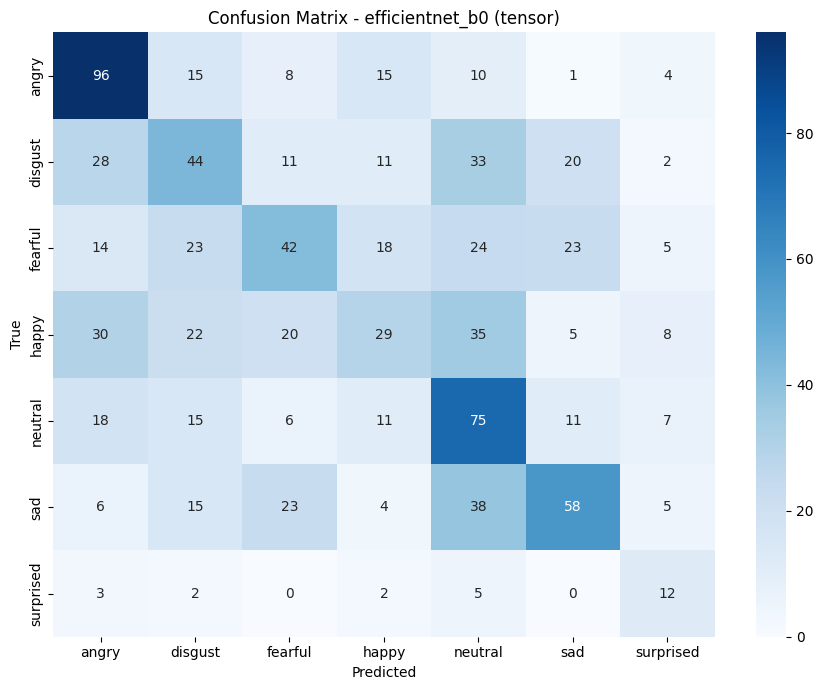

In [37]:

def evaluate_tensor_model_eff(model_arch, model_path, test_loader, class_names):
    model = TensorModelFactory.get_model(model_arch, num_classes=len(class_names), freeze_base=False)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()

    all_y, all_p = [], []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                logits = model(x)
            preds = logits.argmax(dim=1)

            all_y.extend(y.cpu().numpy())
            all_p.extend(preds.cpu().numpy())

    acc = accuracy_score(all_y, all_p)
    f1m = f1_score(all_y, all_p, average='macro', zero_division=0)
    print(f"Test Accuracy: {acc:.4f} | Test F1 macro: {f1m:.4f}\n")
    print(classification_report(all_y, all_p, target_names=class_names, zero_division=0))

    cm = confusion_matrix(all_y, all_p)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix - {model_arch} (tensor)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    del model
    torch.cuda.empty_cache()
    gc.collect()

evaluate_tensor_model_eff(MODEL_ARCH_1, best_phase2_eff, test_loader, class_names)

### Fine tuning con Resnet18

In [38]:
set_global_seed(42)
cleanup_state()

In [39]:
MODELS_SAVE_DIR = "/content/saved_models"
os.makedirs(MODELS_SAVE_DIR, exist_ok=True)
MODEL_ARCH_2 = 'resnet18'
exp_name_18 = f"tensor_{MODEL_ARCH_2}"

train_loader, val_loader, test_loader, class_names, class_weights = build_dataloaders()

phase1_path = os.path.join(MODELS_SAVE_DIR, f"{exp_name_18}resnet_fase1.pth")

model = TensorModelFactory.get_model(MODEL_ARCH_2, num_classes=len(class_names), freeze_base=True)

best_fase1_18 = train_model_tensor(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    save_path=phase1_path,
    epochs=20,
    lr=1e-3,
    patience=6,
    class_weights=class_weights
)

print("Fase 1 mejor modelo:", best_fase1_18)


[01/20] lr=1.0e-03 | train_loss=1.7362 acc=0.2580 | val_loss=1.8251 acc=0.2931 f1m=0.2591
[02/20] lr=1.0e-03 | train_loss=1.4900 acc=0.3585 | val_loss=1.7456 acc=0.3278 f1m=0.2953
[03/20] lr=1.0e-03 | train_loss=1.4301 acc=0.3849 | val_loss=1.8046 acc=0.3170 f1m=0.3037
[04/20] lr=1.0e-03 | train_loss=1.4192 acc=0.3969 | val_loss=1.7345 acc=0.3445 f1m=0.3252
[05/20] lr=1.0e-03 | train_loss=1.4111 acc=0.3977 | val_loss=1.7241 acc=0.3397 f1m=0.3352
[06/20] lr=1.0e-03 | train_loss=1.4189 acc=0.3991 | val_loss=1.7298 acc=0.3397 f1m=0.3197
Early stop activado: 1/6
[07/20] lr=1.0e-03 | train_loss=1.4165 acc=0.4016 | val_loss=1.7328 acc=0.3469 f1m=0.3079
Early stop activado: 2/6
[08/20] lr=1.0e-03 | train_loss=1.4086 acc=0.4105 | val_loss=1.7349 acc=0.3409 f1m=0.3218
Early stop activado: 3/6
[09/20] lr=5.0e-04 | train_loss=1.4099 acc=0.4030 | val_loss=1.7417 acc=0.3397 f1m=0.3151
Early stop activado: 4/6
[10/20] lr=5.0e-04 | train_loss=1.3872 acc=0.4045 | val_loss=1.7211 acc=0.3457 f1m=0.3175


In [40]:
phase2_path = os.path.join(MODELS_SAVE_DIR, f"{exp_name_18}_phase2_unfrozen.pth")

model.load_state_dict(torch.load(best_fase1_18, map_location=device, weights_only=True))
for p in model.parameters():
    p.requires_grad = True

best_fase2_18 = train_model_tensor(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    save_path=phase2_path,
    epochs=50,
    lr=1e-5,
    backbone_lr=1e-5,
    weight_decay=1e-3,
    patience=5,
    class_weights=class_weights
)

print("Fase 2 mejor modelo resnet:", best_fase2_18)

[01/50] lr=1.0e-05 | train_loss=1.3007 acc=0.4506 | val_loss=1.6467 acc=0.3840 f1m=0.3679
[02/50] lr=1.0e-05 | train_loss=1.1693 acc=0.5108 | val_loss=1.6139 acc=0.3900 f1m=0.3723
[03/50] lr=1.0e-05 | train_loss=1.0943 acc=0.5349 | val_loss=1.5856 acc=0.4163 f1m=0.4004
[04/50] lr=1.0e-05 | train_loss=1.0172 acc=0.5965 | val_loss=1.5637 acc=0.4330 f1m=0.4257
[05/50] lr=1.0e-05 | train_loss=0.9497 acc=0.6386 | val_loss=1.5464 acc=0.4390 f1m=0.4328
[06/50] lr=1.0e-05 | train_loss=0.8933 acc=0.6698 | val_loss=1.5433 acc=0.4522 f1m=0.4442
[07/50] lr=1.0e-05 | train_loss=0.8310 acc=0.7080 | val_loss=1.5473 acc=0.4438 f1m=0.4386
Early stop activado: 1/5
[08/50] lr=1.0e-05 | train_loss=0.7847 acc=0.7408 | val_loss=1.5385 acc=0.4557 f1m=0.4518
[09/50] lr=1.0e-05 | train_loss=0.7200 acc=0.7757 | val_loss=1.5433 acc=0.4545 f1m=0.4546
[10/50] lr=1.0e-05 | train_loss=0.6860 acc=0.8073 | val_loss=1.5518 acc=0.4617 f1m=0.4606
[11/50] lr=1.0e-05 | train_loss=0.6340 acc=0.8420 | val_loss=1.5532 acc=0.4

Test Accuracy: 0.4814 | Test F1 macro: 0.4841

              precision    recall  f1-score   support

       angry       0.60      0.70      0.65       149
     disgust       0.38      0.42      0.40       149
     fearful       0.47      0.45      0.46       149
       happy       0.52      0.36      0.42       149
     neutral       0.43      0.57      0.49       143
         sad       0.48      0.39      0.43       149
   surprised       0.57      0.50      0.53        24

    accuracy                           0.48       912
   macro avg       0.49      0.48      0.48       912
weighted avg       0.48      0.48      0.48       912



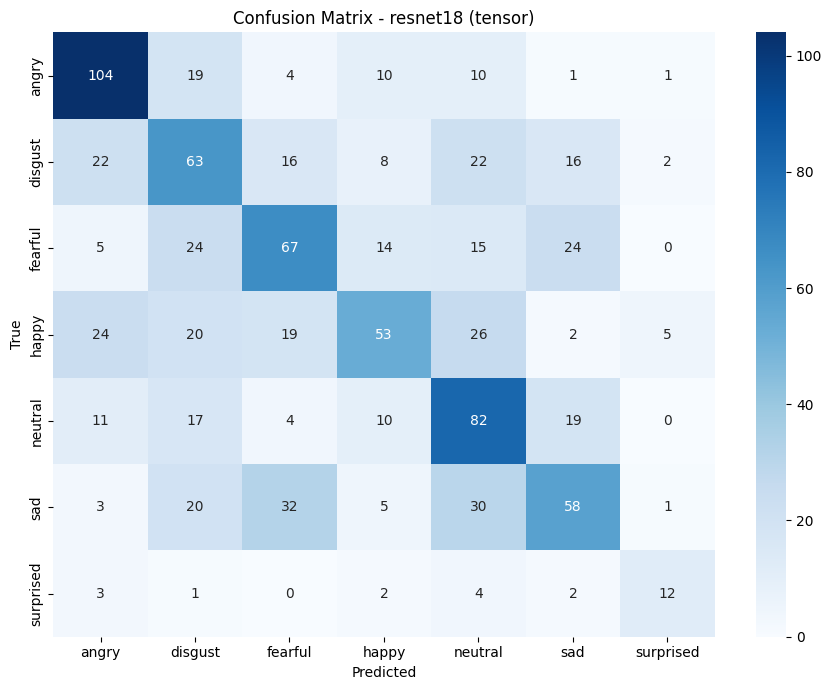

In [41]:
def evaluate_tensor_model(model_arch, model_path, test_loader, class_names):
    model = TensorModelFactory.get_model(model_arch, num_classes=len(class_names), freeze_base=False)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()

    all_y, all_p = [], []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                logits = model(x)
            preds = logits.argmax(dim=1)

            all_y.extend(y.cpu().numpy())
            all_p.extend(preds.cpu().numpy())

    acc = accuracy_score(all_y, all_p)
    f1m = f1_score(all_y, all_p, average='macro', zero_division=0)
    print(f"Test Accuracy: {acc:.4f} | Test F1 macro: {f1m:.4f}\n")
    print(classification_report(all_y, all_p, target_names=class_names, zero_division=0))

    cm = confusion_matrix(all_y, all_p)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix - {model_arch} (tensor)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    del model
    torch.cuda.empty_cache()
    gc.collect()

evaluate_tensor_model(MODEL_ARCH_2, best_fase2_18, test_loader, class_names)

In [ ]:
class ImageModelFactory:
    @staticmethod
    def get_model(model_name, num_classes, freeze_base=True):
        """
        Instancia dinámicamente arquitecturas convolucionales y adapta la última capa.
        """
        if model_name == 'resnet18':
            model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
            if freeze_base:
                for param in model.parameters(): param.requires_grad = False

            num_ftrs = model.fc.in_features
            model.fc = nn.Sequential(nn.Dropout(0.7), nn.Linear(num_ftrs, num_classes))

        elif model_name == 'efficientnet_b0':
            model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
            if freeze_base:
                for param in model.parameters(): param.requires_grad = False

            num_ftrs = model.classifier[1].in_features
            model.classifier[1] = nn.Sequential(nn.Dropout(0.5), nn.Linear(num_ftrs, num_classes))

        else:
            raise ValueError(f"Arquitectura {model_name} no soportada.")

        return model.to(device)

In [ ]:
def train_model(model, train_loader, val_loader, model_save_name, epochs=15, lr=1e-3, patience=5):
    """
    Bucle de entrenamiento con Mixed Precision (AMP) y Early Stopping y LR Scheduler.
    """
    criterion = nn.CrossEntropyLoss()
    # Optimiza solo los parámetros que requieren gradiente (útil en Phase 1)
    # Incrementamos weight_decay a 1e-2 para combatir el Overfitting observado
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=5e-2)

    # Configuramos el LR(Dinamico): Reduce el LR a la mitad si el val_loss no mejora en 2 épocas
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    scaler = torch.amp.GradScaler('cuda')

    best_val_loss = float('inf')
    trigger_times = 0
    save_path = os.path.join(MODELS_SAVE_DIR, f'{model_save_name}.pth')

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            # Forward pass con AMP para ahorro de memoria
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        # Phase de Validación
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        # Actualizamos el Scheduler basado en la métrica de validación
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        print(f"Epoch {epoch+1}/{epochs}[LR:{current_lr:.1e}] | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        # Early Stopping Logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)

        else:
            trigger_times += 1
            print(f"Early stop trigger activado {trigger_times} / {patience}")
            if trigger_times >= patience:
                print(f"--> Early Stopping disparado en época {epoch+1}.")
                break

    return save_path

In [ ]:
set_global_seed(42)
cleanup_state()

In [ ]:
import shutil
# Guardamos los modelos para la siguiente fase (Late fusion)
output_filename = '/content/saved_models'
shutil.make_archive(output_filename, 'zip', MODELS_SAVE_DIR)

# Renombrar el archivo zip para que tenga la extensión .zip
# Esto es un workaround para make_archive que no agrega la extensión por defecto si el base_name ya tiene algo parecido a una extensión.
import os
os.rename('/content/saved_models.zip', '/content/saved_models_final.zip')

!cp /content/saved_models_final.zip /content/drive/MyDrive/saved_models_img_and_tensor.zip